### Notebook 6 — Evaluation & Comparison (Tổng hợp và So sánh)
**Người phụ trách:** Ngô Đức Huân — 52400192 — Integration & Evaluation Lead

**Bộ dữ liệu:** [Online Retail II — UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/502/online+retail+ii)

---

**Input:** Notebook này đọc kết quả đã có sẵn từ 3 Pipeline:
- `Data/Interim/Association_Rules_Result.csv` 
- `Data/Interim/Customer_Segments_Result.csv`
- `Data/Interim/Churn_Model_Results.csv` và `Customer_Churn_Predictions.csv`
- `Models/*.pkl`

**Output:** Bảng so sánh tổng hợp, phân tích chéo giữa 3 kỹ thuật, đề xuất hành động nghiệp vụ cụ thể.

---

**Định vị của dự án — "1 bài toán, 3 góc nhìn":** Cả ba kỹ thuật đều xuất phát từ cùng một câu hỏi lớn
*"Làm sao hiểu và giữ chân khách hàng tốt hơn?"*, nhưng tiếp cận từ ba góc độ bổ sung cho nhau:
- **MBA** trả lời: Khách mua gì thường mua kèm gì? 
- **RFM Clustering** trả lời: Khách hàng nào đáng giá bao nhiêu? 
- **Churn Classification** trả lời: Khách nào sắp rời bỏ?

---

**Mục lục:**
1. Đọc kết quả từ 3 Pipeline
2. Bảng so sánh tổng quát: Mục tiêu, Kỹ thuật, Ưu/Nhược điểm
3. Kiểm tra tính toàn vẹn của các Model
4. Phân tích chéo: Kết nối phân khúc RFM với xác suất Churn
5. Phân tích chéo: Luật kết hợp cho từng phân khúc khách hàng
6. Đề xuất hành động nghiệp vụ
7. Tự đánh giá đóng góp, giới hạn và hướng phát triển
---

### 0. Chuẩn bị môi trường

In [3]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Xác định thư mục gốc project để Notebook có thể import Source/
PROJECT_NOW = Path.cwd()
if (PROJECT_NOW / "Source").exists():
    PROJECT_ROOT_TAM = PROJECT_NOW
else:
    PROJECT_ROOT_TAM = PROJECT_NOW.parent
sys.path.insert(0, str(PROJECT_ROOT_TAM))

from Source.Utils.IO import load_csv, save_to_csv, get_project_root, INTERIM_DATA_DIR, MODELS_DIR
from Source.Utils.Visualization import (set_plot_style, save_current_figure, PRIMARY_COLOR, SECONDARY_COLOR, ALERT_COLOR,)

set_plot_style()
print(f"Thư mục gốc dự án: {get_project_root()}")

Thư mục gốc dự án: D:\Lilith\Customer-Analytics-for-E-Commerce


### 1. Đọc kết quả từ 3 Pipeline

In [5]:
association_rules = load_csv(INTERIM_DATA_DIR / "Association_Rules_Result.csv")
customer_segments = load_csv(INTERIM_DATA_DIR / "Customer_Segments_Result.csv")
churn_results = load_csv(INTERIM_DATA_DIR / "Churn_Model_Results.csv")
churn_predictions = load_csv(INTERIM_DATA_DIR / "Customer_Churn_Predictions.csv")

print(f"Association Rules          : {len(association_rules):,} dòng")
print(f"Customer Segments          : {len(customer_segments):,} dòng")
print(f"Churn Model Results        : {len(churn_results):,} dòng")
print(f"Customer Churn Predictions : {len(churn_predictions):,} dòng")

Association Rules          : 8,777 dòng
Customer Segments          : 5,853 dòng
Churn Model Results        : 3 dòng
Customer Churn Predictions : 5,404 dòng


### 2. Bảng so sánh tổng quát

In [10]:
overview_comparison = pd.DataFrame([
    {
        "Kỹ thuật": "Market Basket Analysis",
        "Mục tiêu nghiệp vụ": "Sản phẩm nào thường được mua cùng nhau?",
        "Thuật toán": "Apriori, FP-Growth",
        "Đầu ra chính": f"{len(association_rules)} luật kết hợp",
        "Ưu điểm nổi bật": "Diễn giải trực tiếp bằng ngôn ngữ nghiệp vụ, không cần nhãn",
        "Giới hạn": "Chỉ phát hiện đồng xuất hiện, không suy ra quan hệ nhân quả",
    },
    {
        "Kỹ thuật": "RFM Clustering",
        "Mục tiêu nghiệp vụ": "Khách hàng nào đáng giá, nên chăm sóc ra sao?",
        "Thuật toán": "K-Means, K-Medoids (PAM tự cài)",
        "Đầu ra chính": f"{customer_segments['Tên phân khúc'].nunique()} phân khúc, "
                        f"{len(customer_segments):,} khách hàng",
        "Ưu điểm nổi bật": "Không cần nhãn, dễ diễn giải bằng đặc điểm R/F/M trung bình",
        "Giới hạn": "Số cụm phải chọn trước; ranh giới giữa các cụm mang tính tương đối",
    },
    {
        "Kỹ thuật": "Churn Classification",
        "Mục tiêu nghiệp vụ": "Khách hàng nào sắp rời bỏ, cần can thiệp ngay?",
        "Thuật toán": "Decision Tree, Random Forest, Naive Bayes",
        "Đầu ra chính": f"Dự đoán cho {len(churn_predictions):,} khách hàng",
        "Ưu điểm nổi bật": "Dự đoán được cho TỪNG khách hàng cụ thể, có xác suất kèm theo",
        "Giới hạn": "Cần tự định nghĩa nhãn (không có sẵn); nhạy với cách chọn cửa sổ thời gian",
    },
])

display(overview_comparison.style.hide(axis="index").set_properties(
        **{
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "top"
        }
    )
)


Kỹ thuật,Mục tiêu nghiệp vụ,Thuật toán,Đầu ra chính,Ưu điểm nổi bật,Giới hạn
Market Basket Analysis,Sản phẩm nào thường được mua cùng nhau?,"Apriori, FP-Growth",8777 luật kết hợp,"Diễn giải trực tiếp bằng ngôn ngữ nghiệp vụ, không cần nhãn","Chỉ phát hiện đồng xuất hiện, không suy ra quan hệ nhân quả"
RFM Clustering,"Khách hàng nào đáng giá, nên chăm sóc ra sao?","K-Means, K-Medoids (PAM tự cài)","3 phân khúc, 5,853 khách hàng","Không cần nhãn, dễ diễn giải bằng đặc điểm R/F/M trung bình",Số cụm phải chọn trước; ranh giới giữa các cụm mang tính tương đối
Churn Classification,"Khách hàng nào sắp rời bỏ, cần can thiệp ngay?","Decision Tree, Random Forest, Naive Bayes","Dự đoán cho 5,404 khách hàng","Dự đoán được cho TỪNG khách hàng cụ thể, có xác suất kèm theo",Cần tự định nghĩa nhãn (không có sẵn); nhạy với cách chọn cửa sổ thời gian


### 3. Kiểm tra tính toàn vẹn của các Model

In [12]:
# ============================================================
# 3. KIỂM TRA TÍNH TOÀN VẸN CỦA CÁC MODEL ĐÃ LƯU
# ============================================================

model_files = {
    "KMeans RFM": "KMeans_RFM.pkl",
    "Decision Tree": "Decision_Tree_Churn.pkl",
    "Random Forest": "Random_Forest_Churn.pkl",
    "Naive Bayes": "Naive_Bayes_Churn.pkl",
}

print("KIỂM TRA LẠI TỪNG MODEL")
print("-" * 70)

for model_name, filename in model_files.items():
    file_path = MODELS_DIR / filename
    if not file_path.exists():
        print(f"✗ {model_name:<15}  |  {filename:<30} — Không tìm thấy Model")
        continue
    try:
        model = joblib.load(file_path)
        file_size_kb = file_path.stat().st_size / 1024
        model_type = type(model).__name__

        print(f" {model_name:<15}  —  {filename:<30}  —  Load thành công  —  {file_size_kb:,.0f} KB  —  Loại: {model_type}")

    except Exception as error:
        print(f"✗ {model_name:<15}  —  {filename:<30}  —  Lỗi khi load: {error}")

KIỂM TRA LẠI TỪNG MODEL
----------------------------------------------------------------------
 KMeans RFM       —  KMeans_RFM.pkl                  —  Load thành công  —  24 KB  —  Loại: KMeans
 Decision Tree    —  Decision_Tree_Churn.pkl         —  Load thành công  —  11 KB  —  Loại: DecisionTreeClassifier
 Random Forest    —  Random_Forest_Churn.pkl         —  Load thành công  —  6,384 KB  —  Loại: RandomForestClassifier
 Naive Bayes      —  Naive_Bayes_Churn.pkl           —  Load thành công  —  1 KB  —  Loại: GaussianNB


### 4. Phân tích chéo: Kết nối phân khúc RFM với xác suất Churn

In [21]:
cross_analysis = customer_segments.merge(
    churn_predictions[["Customer ID", "Churn thực tế", "Xác suất Churn", "Churn dự đoán",]],
    on="Customer ID",
    how="inner",
    validate="one_to_one"
)

print(f"Số khách hàng khớp được giữa 2 bảng: {len(cross_analysis):,} / {len(customer_segments):,}")
print("Phần chênh lệch là do Customer Segments chứa toàn bộ khách hàng, trong khi Churn Predictions chỉ chứa khách hàng thuộc tập Test")

segment_churn_summary = (
    cross_analysis
    .groupby("Tên phân khúc")
    .agg(
        **{
            "Số khách hàng": ("Customer ID", "nunique"),
            "Tỷ lệ Churn thực tế": (
                "Churn thực tế",
                "mean"
            ),
            "Xác suất Churn trung bình": (
                "Xác suất Churn",
                "mean"
            ),
            "Tỷ lệ dự đoán Churn": (
                "Churn dự đoán",
                "mean"
            ),
        }
    )
)

# Chuyển các tỷ lệ sang %
percentage_columns = ["Tỷ lệ Churn thực tế", "Xác suất Churn trung bình", "Tỷ lệ dự đoán Churn",]
segment_churn_summary[percentage_columns] *= 100
segment_churn_summary = (segment_churn_summary.round(3).sort_values( "Xác suất Churn trung bình", ascending=False))

display(segment_churn_summary)

Số khách hàng khớp được giữa 2 bảng: 5,404 / 5,853
Phần chênh lệch là do Customer Segments chứa toàn bộ khách hàng, trong khi Churn Predictions chỉ chứa khách hàng thuộc tập Test


,Số khách hàng,Tỷ lệ Churn thực tế,Xác suất Churn trung bình,Tỷ lệ dự đoán Churn
Tên phân khúc,,,,
Khách hàng có nguy cơ rời bỏ,1824,100.000,99.059,100.000
Khách hàng trung thành,1915,54.830,81.009,99.739
Khách VIP,1665,24.144,32.772,31.231


Đã lưu biểu đồ: D:\Lilith\Customer-Analytics-for-E-Commerce\Figures\16. Segment vs Churn Probability.png


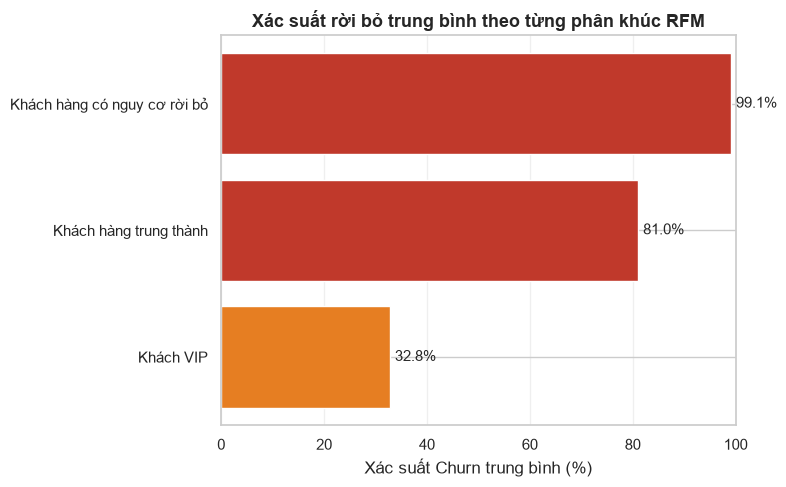

In [23]:
# Sắp xếp tăng dần để thanh có rủi ro cao nhất nằm trên cùng
plot_data = segment_churn_summary.sort_values("Xác suất Churn trung bình", ascending=True)
fig, ax = plt.subplots(figsize=(8, 5))

colors_by_risk = [ALERT_COLOR if value > 60 else SECONDARY_COLOR if value > 30 else PRIMARY_COLOR for value in plot_data["Xác suất Churn trung bình"]]

bars = ax.barh(plot_data.index, plot_data["Xác suất Churn trung bình"], color=colors_by_risk)
ax.set_xlabel("Xác suất Churn trung bình (%)")
ax.set_title("Xác suất rời bỏ trung bình theo từng phân khúc RFM")
ax.set_xlim(0, 100)

for bar, value in zip(bars, plot_data["Xác suất Churn trung bình"]):
    ax.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center")
    
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
save_current_figure("16. Segment vs Churn Probability.png")
plt.show()

#### **Nhận xét**

Kết quả đối chiếu giữa **RFM Clustering** và **Churn Classification** cho thấy hai phương pháp khác nhau đang đưa ra **xu hướng tương đối nhất quán**. Trong tập khách hàng có mặt ở cả hai pipeline, phân khúc **“Khách VIP”** có xác suất Churn trung bình thấp nhất (`32.77%`) và tỷ lệ Churn thực tế cũng thấp nhất (`24.14%`). Ngược lại, phân khúc **“Khách hàng có nguy cơ rời bỏ”** có xác suất Churn trung bình rất cao (`99.06%`) và tỷ lệ Churn thực tế đạt `100%`.

Kết quả này cho thấy đặc điểm hành vi được phát hiện bằng RFM, đặc biệt là mức **Recency cao** ở nhóm có nguy cơ, có sự phù hợp đáng kể với tín hiệu mà mô hình Classification sử dụng để dự đoán Churn. Đây là một dạng **đối chiếu chéo giữa hai phương pháp**, giúp tăng mức độ nhất quán của kết quả phân tích, thay vì xem từng pipeline hoàn toàn tách biệt.

Một điểm đáng chú ý khác là phân khúc **“Khách hàng trung thành”** có xác suất Churn trung bình khá cao (`81.01%`), trong khi tỷ lệ Churn thực tế là `54.83%`. Điều này cho thấy tên phân khúc dựa trên RFM không đồng nghĩa trực tiếp với mức rủi ro Churn thấp. Trong trường hợp này, mô hình có xu hướng cảnh báo Churn mạnh hơn mức xảy ra thực tế, Recall cao (`0.9164`) nhưng Precision thấp hơn các mô hình còn lại (`0.7057`).

Do đó, kết quả phân tích chéo vừa cung cấp bằng chứng về **sự nhất quán ở hai nhóm cực trị**, vừa chỉ ra một vùng cần xem xét thêm ở nhóm “Khách hàng trung thành”.

### 5. Phân tích chéo: Luật kết hợp cho từng phân khúc khách hàng

Kết nối MBA với RFM: liệu khách hàng ở các phân khúc khác nhau có xu hướng xuất hiện trong các luật
kết hợp có Lift cao khác nhau hay không? Đây là bước gợi ý cho các chiến dịch cross-sell được cá nhân
hoá theo từng phân khúc.

In [33]:
# TOP 5 LUẬT KẾT HỢP 1 → 1 CÓ LIFT CAO NHẤT

def count_items(itemset):
    if pd.isna(itemset) or str(itemset).strip() == "":
        return 0

    return len([item.strip() for item in str(itemset).split(",") if item.strip()])


# Chỉ giữ các luật có dạng 1 sản phẩm → 1 sản phẩm
single_item_rules = association_rules[
    (association_rules["Antecedents"].apply(count_items) == 1)
    & (association_rules["Consequents"].apply(count_items) == 1)
].copy()


# Chỉ xét các luật có Support từ 2% trở lên
filtered_rules = single_item_rules[
    single_item_rules["Support"] >= 0.02
].copy()


# Sắp xếp theo Lift giảm dần; nếu Lift bằng nhau thì ưu tiên Confidence cao hơn
top_rules_by_lift = (filtered_rules.sort_values(["Lift", "Confidence"], ascending=[False, False]).head(5).reset_index(drop=True))

print("TOP 5 LUẬT KẾT HỢP CÓ LIFT CAO NHẤT (Support ≥ 0.02):\n")

for idx, row in top_rules_by_lift.iterrows():
    print(f"{idx + 1}. [{row['Antecedents Name']}] → [{row['Consequents Name']}]")
    print(f"   Support = {row['Support']:.4f}  |  Confidence = {row['Confidence']:.3f}  |  Lift = {row['Lift']:.2f}  |  Kulczynski = {row['Kulczynski']:.3f}")
    print()

TOP 5 LUẬT KẾT HỢP CÓ LIFT CAO NHẤT (Support ≥ 0.02):

1. [PINK REGENCY TEACUP AND SAUCER] → [GREEN REGENCY TEACUP AND SAUCER]
   Support = 0.0209  |  Confidence = 0.837  |  Lift = 25.53  |  Kulczynski = 0.737

2. [GREEN REGENCY TEACUP AND SAUCER] → [PINK REGENCY TEACUP AND SAUCER]
   Support = 0.0209  |  Confidence = 0.638  |  Lift = 25.53  |  Kulczynski = 0.737

3. [GREEN REGENCY TEACUP AND SAUCER] → [ROSES REGENCY TEACUP AND SAUCER ]
   Support = 0.0250  |  Confidence = 0.763  |  Lift = 22.17  |  Kulczynski = 0.745

4. [ROSES REGENCY TEACUP AND SAUCER ] → [GREEN REGENCY TEACUP AND SAUCER]
   Support = 0.0250  |  Confidence = 0.726  |  Lift = 22.17  |  Kulczynski = 0.745

5. [ALARM CLOCK BAKELIKE RED ] → [ALARM CLOCK BAKELIKE GREEN]
   Support = 0.0202  |  Confidence = 0.613  |  Lift = 19.92  |  Kulczynski = 0.635



**Gợi ý kết nối nghiệp vụ:**

Các luật kết hợp có Lift cao trong dữ liệu tập trung vào những sản phẩm thường được mua cùng nhau, trong đó có nhiều sản phẩm thuộc cùng dòng hoặc cùng bộ sưu tập (ví dụ các sản phẩm khác màu hoặc có thiết kế tương đồng). Những mối liên hệ này có thể được sử dụng làm cơ sở cho các chương trình **cross-selling**, chẳng hạn gợi ý sản phẩm bổ sung trong email marketing hoặc khi khách hàng thực hiện mua hàng.

Xét theo đặc điểm các phân khúc RFM, **Khách hàng trung thành** có tần suất mua lặp lại nhưng giá trị tiền tệ trung bình thấp hơn đáng kể so với nhóm **Khách VIP**. Vì vậy, các gợi ý sản phẩm cùng dòng có thể được xem là **một hướng thử nghiệm phù hợp** để tăng giá trị trên mỗi đơn hàng của nhóm này. Trong khi đó, đối với **Khách hàng có nguy cơ rời bỏ**, ưu tiên trước mắt có thể là các hoạt động kích hoạt lại và duy trì tương tác thay vì chỉ tập trung vào gợi ý mua thêm.

*Cần lưu ý rằng các luật kết hợp hiện tại được khai phá trên toàn bộ dữ liệu giao dịch và chưa chứa `Customer ID` hoặc thông tin phân khúc. Do đó, chưa thể xác định trực tiếp luật nào được tạo ra hoặc có hiệu quả cao hơn trong từng phân khúc khách hàng. Kết nối giữa Association Rules và RFM trong phiên bản hiện tại chỉ dừng ở mức **gợi ý chiến lược dựa trên đặc điểm phân khúc**. Một hướng mở rộng là thực hiện Market Basket Analysis riêng cho từng phân khúc sau khi xây dựng được dữ liệu giao dịch có đầy đủ thông tin khách hàng.*


### 6. Đề xuất hành động nghiệp vụ cụ thể

In [35]:
action_plan = pd.DataFrame([
    {
        "Phân khúc": "Khách VIP",
        "Đặc điểm chính": (
            "Mua gần đây, thường xuyên, giá trị tiền tệ trung bình cao; "
            "xác suất churn thấp hơn tương đối so với các phân khúc còn lại"
        ),
        "Rủi ro/Cơ hội": (
            "Giá trị khách hàng cao; cần duy trì quan hệ và hạn chế nguy cơ mất "
            "khách hàng có giá trị lớn"
        ),
        "Hành động đề xuất": (
            "Chương trình khách hàng thân thiết, ưu đãi độc quyền, "
            "chăm sóc và cá nhân hóa trải nghiệm"
        ),
    },
    {
        "Phân khúc": "Khách trung thành",
        "Đặc điểm chính": (
            "Có mua lặp lại nhưng giá trị tiền tệ trung bình thấp hơn nhóm VIP; "
            "xác suất churn theo mô hình ở mức cao"
        ),
        "Rủi ro/Cơ hội": (
            "Có cơ hội tăng giá trị mỗi đơn hàng thông qua cross-selling "
            "và gợi ý sản phẩm liên quan"
        ),
        "Hành động đề xuất": (
            "Gợi ý mua kèm dựa trên các luật kết hợp có Lift cao (Mục 5), "
            "khuyến khích mua theo bộ hoặc mua sản phẩm bổ sung"
        ),
    },
    {
        "Phân khúc": "Khách có nguy cơ rời bỏ",
        "Đặc điểm chính": (
            "Đã lâu không quay lại; xác suất churn theo mô hình ở mức rất cao"
        ),
        "Rủi ro/Cơ hội": (
            "Rủi ro mất khách hàng cao; cần tập trung vào hoạt động "
            "tái kích hoạt và duy trì tương tác"
        ),
        "Hành động đề xuất": (
            "Chiến dịch tái kích hoạt: email nhắc nhở, ưu đãi có thời hạn, "
            "và thông điệp cá nhân hóa theo lịch sử mua hàng"
        ),
    },
])

display(
    action_plan.style
    .hide(axis="index")
    .set_properties(
        **{
            "white-space": "normal",
            "text-align": "left",
            "vertical-align": "top",
        }
    )
)

Phân khúc,Đặc điểm chính,Rủi ro/Cơ hội,Hành động đề xuất
Khách VIP,"Mua gần đây, thường xuyên, giá trị tiền tệ trung bình cao; xác suất churn thấp hơn tương đối so với các phân khúc còn lại",Giá trị khách hàng cao; cần duy trì quan hệ và hạn chế nguy cơ mất khách hàng có giá trị lớn,"Chương trình khách hàng thân thiết, ưu đãi độc quyền, chăm sóc và cá nhân hóa trải nghiệm"
Khách trung thành,Có mua lặp lại nhưng giá trị tiền tệ trung bình thấp hơn nhóm VIP; xác suất churn theo mô hình ở mức cao,Có cơ hội tăng giá trị mỗi đơn hàng thông qua cross-selling và gợi ý sản phẩm liên quan,"Gợi ý mua kèm dựa trên các luật kết hợp có Lift cao (Mục 5), khuyến khích mua theo bộ hoặc mua sản phẩm bổ sung"
Khách có nguy cơ rời bỏ,Đã lâu không quay lại; xác suất churn theo mô hình ở mức rất cao,Rủi ro mất khách hàng cao; cần tập trung vào hoạt động tái kích hoạt và duy trì tương tác,"Chiến dịch tái kích hoạt: email nhắc nhở, ưu đãi có thời hạn, và thông điệp cá nhân hóa theo lịch sử mua hàng"


In [45]:
# TÓM TẮT CUỐI CÙNG CỦA TOÀN BỘ DỰ ÁN
final_summary = {
    "Số khách hàng tổng": int(customer_segments["Customer ID"].nunique()),
    "Số phân khúc RFM": int(customer_segments["Tên phân khúc"].nunique()),
    "Số luật kết hợp": int(len(association_rules)),
    "Mô hình Churn có F1 cao nhất": str(churn_results.loc[churn_results["F1"].idxmax(), "Model name"]),
    "F1 cao nhất": float(churn_results["F1"].max()),
    "AUC cao nhất": float(churn_results["AUC"].max()),
}

final_summary_df = pd.DataFrame.from_dict(final_summary, orient="index", columns=["Giá trị"])
display(final_summary_df)

,Giá trị
Số khách hàng tổng,5853
Số phân khúc RFM,3
Số luật kết hợp,8777
Mô hình Churn có F1 cao nhất,Naive Bayes
F1 cao nhất,0.7973
AUC cao nhất,0.7872
